In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# 0. Import database

In [2]:
url = "https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/credit.csv"

# Importa Base, separação por tabulação
base = pd.read_csv(url, sep="\t", encoding="Latin-1")

# Cria uma lista com os nomes das colunas
header = ['ID_CLIENTE', 'TIPO_FUNCIONARIO', 'DIA_PAGAMENTO', 'TIPO_ENVIO_APLICACAO', 'QUANT_CARTOES_ADICIONAIS',
          'TIPO_ENDERECO_POSTAL', 'SEXO', 'ESTADO_CIVIL', 'QUANT_DEPENDENTES', 'NIVEL_EDUCACIONAL', 'ESTADO_NASCIMENTO',
          'CIDADE_NASCIMENTO', 'NACIONALIDADE', 'ESTADO_RESIDENCIAL', 'CIDADE_RESIDENCIAL', 'BAIRRO_RESIDENCIAL',
          'FLAG_TELEFONE_RESIDENCIAL', 'CODIGO_AREA_TELEFONE_RESIDENCIAL', 'TIPO_RESIDENCIA', 'MESES_RESIDENCIA',
          'FLAG_TELEFONE_MOVEL', 'FLAG_EMAIL', 'RENDA_PESSOAL_MENSAL', 'OUTRAS_RENDAS', 'FLAG_VISA', 'FLAG_MASTERCARD',
          'FLAG_DINERS', 'FLAG_AMERICAN_EXPRESS', 'FLAG_OUTROS_CARTOES', 'QUANT_CONTAS_BANCARIAS',
          'QUANT_CONTAS_BANCARIAS_ESPECIAIS', 'VALOR_PATRIMONIO_PESSOAL', 'QUANT_CARROS', 'EMPRESA',
          'ESTADO_PROFISSIONAL', 'CIDADE_PROFISSIONAL', 'BAIRRO_PROFISSIONAL', 'FLAG_TELEFONE_PROFISSIONAL',
          'CODIGO_AREA_TELEFONE_PROFISSIONAL', 'MESES_NO_TRABALHO', 'CODIGO_PROFISSAO', 'TIPO_OCUPACAO',
          'CODIGO_PROFISSAO_CONJUGE', 'NIVEL_EDUCACIONAL_CONJUGE', 'FLAG_DOCUMENTO_RESIDENCIAL', 'FLAG_RG',
          'FLAG_CPF', 'FLAG_COMPROVANTE_RENDA', 'PRODUTO', 'FLAG_REGISTRO_ACSP', 'IDADE', 'CEP_RESIDENCIAL_3',
          'CEP_PROFISSIONAL_3', 'ROTULO_ALVO_MAU=1'
]

# Adiciona nome as colunas do data frame
base.columns = header
base

C:\Users\ivan_\AppData\Local\Temp\ipykernel_39068\158269861.py:4: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  base = pd.read_csv(url, sep="\t", encoding="Latin-1")


,ID_CLIENTE,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL_3,CEP_PROFISSIONAL_3,ROTULO_ALVO_MAU=1
0,2,C,15,Carga,0,1,F,2,0,0,...,0,0,0,0,1,N,34,230,230,1
1,3,C,5,Web,0,1,F,2,0,0,...,0,0,0,0,1,N,27,591,591,0
2,4,C,20,Web,0,1,F,2,0,0,...,0,0,0,0,1,N,61,545,545,0
3,5,C,10,Web,0,1,M,2,0,0,...,0,0,0,0,1,N,48,235,235,1
4,6,C,10,0,0,1,M,2,0,0,...,0,0,0,0,2,N,40,371,371,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,49996,C,10,0,0,1,F,1,2,0,...,0,0,0,0,1,N,36,591,591,1
49995,49997,C,25,0,0,1,F,1,0,0,...,0,0,0,0,2,N,21,186,186,0
49996,49998,C,5,Web,0,1,M,2,3,0,...,0,0,0,0,1,N,41,715,715,0
49997,49999,C,1,Web,0,1,F,1,1,0,...,0,0,0,0,1,N,28,320,320,1


In [3]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ID_CLIENTE                         49999 non-null  int64  
 1   TIPO_FUNCIONARIO                   49999 non-null  object 
 2   DIA_PAGAMENTO                      49999 non-null  int64  
 3   TIPO_ENVIO_APLICACAO               49999 non-null  object 
 4   QUANT_CARTOES_ADICIONAIS           49999 non-null  int64  
 5   TIPO_ENDERECO_POSTAL               49999 non-null  int64  
 6   SEXO                               49999 non-null  object 
 7   ESTADO_CIVIL                       49999 non-null  int64  
 8   QUANT_DEPENDENTES                  49999 non-null  int64  
 9   NIVEL_EDUCACIONAL                  49999 non-null  int64  
 10  ESTADO_NASCIMENTO                  49999 non-null  object 
 11  CIDADE_NASCIMENTO                  49999 non-null  obj

# 2. Teste 02

## 2.1 Tratamentos dos dados

### 2.1.1 Remoção colunas não necessárias

In [4]:
base["TIPO_ENVIO_APLICACAO"].value_counts()

TIPO_ENVIO_APLICACAO
Web      28205
0        19461
Carga     2333
Name: count, dtype: int64

In [5]:
base["QUANT_CARTOES_ADICIONAIS"].value_counts()

QUANT_CARTOES_ADICIONAIS
0    49999
Name: count, dtype: int64

In [6]:
base["TIPO_ENDERECO_POSTAL"].value_counts()

TIPO_ENDERECO_POSTAL
1    49672
2      327
Name: count, dtype: int64

In [7]:
base["ESTADO_CIVIL"].value_counts()

ESTADO_CIVIL
2    25967
1    15286
4     4206
6     1876
5     1296
3      632
7      534
0      202
Name: count, dtype: int64

In [8]:
base["QUANT_DEPENDENTES"].value_counts()

QUANT_DEPENDENTES
0     33655
1      7003
2      5363
3      2465
4       860
5       365
6       139
7        65
8        35
9        14
10       13
11        7
12        6
13        4
14        3
15        1
53        1
Name: count, dtype: int64

In [9]:
base["NIVEL_EDUCACIONAL"].value_counts()

NIVEL_EDUCACIONAL
0    49999
Name: count, dtype: int64

In [10]:
base["NACIONALIDADE"].value_counts()

NACIONALIDADE
1    47883
0     2018
2       98
Name: count, dtype: int64

In [11]:
base["MESES_RESIDENCIA"].value_counts()

MESES_RESIDENCIA
1.0      7340
0.0      4695
10.0     3799
5.0      3561
2.0      3217
         ... 
101.0       1
66.0        1
78.0        1
81.0        1
89.0        1
Name: count, Length: 88, dtype: int64

In [12]:
base["QUANT_CONTAS_BANCARIAS"].value_counts()

QUANT_CONTAS_BANCARIAS
0    32121
1    17864
2       14
Name: count, dtype: int64

In [13]:
base["QUANT_CONTAS_BANCARIAS_ESPECIAIS"].value_counts()

QUANT_CONTAS_BANCARIAS_ESPECIAIS
0    32121
1    17864
2       14
Name: count, dtype: int64

In [14]:
base["VALOR_PATRIMONIO_PESSOAL"].value_counts()

VALOR_PATRIMONIO_PESSOAL
0.0          47608
30000.0        222
25000.0        198
50000.0        196
15000.0        185
             ...  
5000000.0        1
220000.0         1
53000.0          1
401.0            1
10500.0          1
Name: count, Length: 153, dtype: int64

In [15]:
base["QUANT_CARROS"].value_counts()

QUANT_CARROS
0    33192
1    16807
Name: count, dtype: int64

In [16]:
base["CODIGO_PROFISSAO"].value_counts()

CODIGO_PROFISSAO
9.0     30091
11.0     3545
0.0      3540
2.0      2827
12.0      489
10.0      425
16.0      344
13.0      313
7.0       216
8.0       144
6.0       136
15.0       63
17.0       35
4.0        27
3.0        18
5.0        12
14.0        9
1.0         8
18.0        1
Name: count, dtype: int64

In [17]:
base["TIPO_OCUPACAO"].value_counts()

TIPO_OCUPACAO
2.0    16947
1.0     8742
4.0     6999
5.0     6891
0.0     2788
3.0      319
Name: count, dtype: int64

In [18]:
base["FLAG_COMPROVANTE_RENDA"].value_counts()

FLAG_COMPROVANTE_RENDA
0    49999
Name: count, dtype: int64

In [19]:
base["PRODUTO"].value_counts()

PRODUTO
1    42689
2     6015
7     1295
Name: count, dtype: int64

In [20]:
lista_drop_features=[
    "ID_CLIENTE",
    "TIPO_FUNCIONARIO",
    "DIA_PAGAMENTO",
    "TIPO_ENVIO_APLICACAO",
    "QUANT_CARTOES_ADICIONAIS",
    "TIPO_ENDERECO_POSTAL",
    "NIVEL_EDUCACIONAL",
    "ESTADO_NASCIMENTO",
    "CIDADE_NASCIMENTO",
    "NACIONALIDADE",
    "ESTADO_RESIDENCIAL",
    "CIDADE_RESIDENCIAL",
    "BAIRRO_RESIDENCIAL",
    "BAIRRO_PROFISSIONAL",
    "FLAG_TELEFONE_RESIDENCIAL",
    "CODIGO_AREA_TELEFONE_RESIDENCIAL",
    "MESES_RESIDENCIA",
    "FLAG_TELEFONE_MOVEL",
    "FLAG_EMAIL",
    "QUANT_CONTAS_BANCARIAS_ESPECIAIS",
    "VALOR_PATRIMONIO_PESSOAL",
    "QUANT_CARROS",
    "EMPRESA",
    "ESTADO_PROFISSIONAL",
    "CIDADE_PROFISSIONAL",
    "BAIRRO_PROFISSIONAL",
    "FLAG_TELEFONE_PROFISSIONAL",
    "CODIGO_AREA_TELEFONE_PROFISSIONAL",
    "MESES_NO_TRABALHO",
    "CODIGO_PROFISSAO",
    "CODIGO_PROFISSAO_CONJUGE",
    "NIVEL_EDUCACIONAL_CONJUGE",
    "FLAG_DOCUMENTO_RESIDENCIAL",
    "FLAG_RG",
    "FLAG_CPF",
    "FLAG_COMPROVANTE_RENDA",
    "FLAG_REGISTRO_ACSP",
    "CEP_RESIDENCIAL_3",
    "CEP_PROFISSIONAL_3",
    "FLAG_VISA",
    "FLAG_MASTERCARD",
    "FLAG_AMERICAN_EXPRESS",
    "FLAG_OUTROS_CARTOES",
    "QUANT_CONTAS_BANCARIAS",
    ]

In [21]:
base = base.drop(columns=lista_drop_features)

In [22]:
base.isnull().sum()

SEXO                       0
ESTADO_CIVIL               0
QUANT_DEPENDENTES          0
TIPO_RESIDENCIA         1349
RENDA_PESSOAL_MENSAL       0
OUTRAS_RENDAS              0
FLAG_DINERS                0
TIPO_OCUPACAO           7313
PRODUTO                    0
IDADE                      0
ROTULO_ALVO_MAU=1          0
dtype: int64

In [23]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SEXO                  49999 non-null  object 
 1   ESTADO_CIVIL          49999 non-null  int64  
 2   QUANT_DEPENDENTES     49999 non-null  int64  
 3   TIPO_RESIDENCIA       48650 non-null  float64
 4   RENDA_PESSOAL_MENSAL  49999 non-null  float64
 5   OUTRAS_RENDAS         49999 non-null  float64
 6   FLAG_DINERS           49999 non-null  int64  
 7   TIPO_OCUPACAO         42686 non-null  float64
 8   PRODUTO               49999 non-null  int64  
 9   IDADE                 49999 non-null  int64  
 10  ROTULO_ALVO_MAU=1     49999 non-null  int64  
dtypes: float64(4), int64(6), object(1)
memory usage: 4.2+ MB


### 2.1.2 Separação das bases

In [24]:
base_numerica = base.select_dtypes(exclude=['object'])
base_objeto = base.select_dtypes(exclude=['int64', 'float64'])

In [25]:
base_objeto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   SEXO    49999 non-null  object
dtypes: object(1)
memory usage: 390.7+ KB


### 2.1.3 SEXO Dummies

In [26]:
sexo = pd.get_dummies(base_objeto['SEXO'], drop_first=True)
sexo.head()

,F,M,N
0,True,False,False
1,True,False,False
2,True,False,False
3,False,True,False
4,False,True,False


In [27]:
base_numerica.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ESTADO_CIVIL          49999 non-null  int64  
 1   QUANT_DEPENDENTES     49999 non-null  int64  
 2   TIPO_RESIDENCIA       48650 non-null  float64
 3   RENDA_PESSOAL_MENSAL  49999 non-null  float64
 4   OUTRAS_RENDAS         49999 non-null  float64
 5   FLAG_DINERS           49999 non-null  int64  
 6   TIPO_OCUPACAO         42686 non-null  float64
 7   PRODUTO               49999 non-null  int64  
 8   IDADE                 49999 non-null  int64  
 9   ROTULO_ALVO_MAU=1     49999 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 3.8 MB


### 2.1.4 Concatenando as bases

In [28]:
base_tratada = pd.concat([base_numerica],axis=1)
base_tratada.head()

,ESTADO_CIVIL,QUANT_DEPENDENTES,TIPO_RESIDENCIA,RENDA_PESSOAL_MENSAL,OUTRAS_RENDAS,FLAG_DINERS,TIPO_OCUPACAO,PRODUTO,IDADE,ROTULO_ALVO_MAU=1
0,2,0,1.0,750.0,0.0,0,4.0,1,34,1
1,2,0,1.0,500.0,0.0,0,NaN,1,27,0
2,2,0,NaN,500.0,0.0,0,NaN,1,61,0
3,2,0,1.0,1200.0,0.0,0,5.0,1,48,1
4,2,0,1.0,500.0,0.0,0,2.0,2,40,1


In [29]:
base_tratada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ESTADO_CIVIL          49999 non-null  int64  
 1   QUANT_DEPENDENTES     49999 non-null  int64  
 2   TIPO_RESIDENCIA       48650 non-null  float64
 3   RENDA_PESSOAL_MENSAL  49999 non-null  float64
 4   OUTRAS_RENDAS         49999 non-null  float64
 5   FLAG_DINERS           49999 non-null  int64  
 6   TIPO_OCUPACAO         42686 non-null  float64
 7   PRODUTO               49999 non-null  int64  
 8   IDADE                 49999 non-null  int64  
 9   ROTULO_ALVO_MAU=1     49999 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 3.8 MB


## 2.2 Inputando dados

### 2.2.1 Inputando mediana

In [30]:
# mediana
median_imputer = SimpleImputer(strategy='median')
df_median = pd.DataFrame(median_imputer.fit_transform(base_tratada), columns=base_tratada.columns)

df_median

,ESTADO_CIVIL,QUANT_DEPENDENTES,TIPO_RESIDENCIA,RENDA_PESSOAL_MENSAL,OUTRAS_RENDAS,FLAG_DINERS,TIPO_OCUPACAO,PRODUTO,IDADE,ROTULO_ALVO_MAU=1
0,2.0,0.0,1.0,750.00,0.0,0.0,4.0,1.0,34.0,1.0
1,2.0,0.0,1.0,500.00,0.0,0.0,2.0,1.0,27.0,0.0
2,2.0,0.0,1.0,500.00,0.0,0.0,2.0,1.0,61.0,0.0
3,2.0,0.0,1.0,1200.00,0.0,0.0,5.0,1.0,48.0,1.0
4,2.0,0.0,1.0,500.00,0.0,0.0,2.0,2.0,40.0,1.0
...,...,...,...,...,...,...,...,...,...,...
49994,1.0,2.0,1.0,1451.00,0.0,0.0,4.0,1.0,36.0,1.0
49995,1.0,0.0,1.0,450.00,0.0,0.0,2.0,2.0,21.0,0.0
49996,2.0,3.0,2.0,1555.00,0.0,0.0,2.0,1.0,41.0,0.0
49997,1.0,1.0,1.0,1443.27,0.0,0.0,2.0,1.0,28.0,1.0


### 2.2.2 Inputando media

In [31]:
# media
mean_imputer = SimpleImputer(strategy='mean')
df_mean = pd.DataFrame(mean_imputer.fit_transform(base_tratada), columns=base_tratada.columns)

df_mean

,ESTADO_CIVIL,QUANT_DEPENDENTES,TIPO_RESIDENCIA,RENDA_PESSOAL_MENSAL,OUTRAS_RENDAS,FLAG_DINERS,TIPO_OCUPACAO,PRODUTO,IDADE,ROTULO_ALVO_MAU=1
0,2.0,0.0,1.00000,750.00,0.0,0.0,4.000000,1.0,34.0,1.0
1,2.0,0.0,1.00000,500.00,0.0,0.0,2.484281,1.0,27.0,0.0
2,2.0,0.0,1.25223,500.00,0.0,0.0,2.484281,1.0,61.0,0.0
3,2.0,0.0,1.00000,1200.00,0.0,0.0,5.000000,1.0,48.0,1.0
4,2.0,0.0,1.00000,500.00,0.0,0.0,2.000000,2.0,40.0,1.0
...,...,...,...,...,...,...,...,...,...,...
49994,1.0,2.0,1.00000,1451.00,0.0,0.0,4.000000,1.0,36.0,1.0
49995,1.0,0.0,1.00000,450.00,0.0,0.0,2.484281,2.0,21.0,0.0
49996,2.0,3.0,2.00000,1555.00,0.0,0.0,2.000000,1.0,41.0,0.0
49997,1.0,1.0,1.00000,1443.27,0.0,0.0,2.000000,1.0,28.0,1.0


### 2.2.3 Inputando valor dos visinhos próximos (KNN)

In [32]:
# KNN Imputer
knn_imputer = KNNImputer(n_neighbors=2)
df_knn = pd.DataFrame(knn_imputer.fit_transform(base_tratada), columns=base_tratada.columns)

df_knn

,ESTADO_CIVIL,QUANT_DEPENDENTES,TIPO_RESIDENCIA,RENDA_PESSOAL_MENSAL,OUTRAS_RENDAS,FLAG_DINERS,TIPO_OCUPACAO,PRODUTO,IDADE,ROTULO_ALVO_MAU=1
0,2.0,0.0,1.0,750.00,0.0,0.0,4.0,1.0,34.0,1.0
1,2.0,0.0,1.0,500.00,0.0,0.0,2.0,1.0,27.0,0.0
2,2.0,0.0,1.0,500.00,0.0,0.0,5.0,1.0,61.0,0.0
3,2.0,0.0,1.0,1200.00,0.0,0.0,5.0,1.0,48.0,1.0
4,2.0,0.0,1.0,500.00,0.0,0.0,2.0,2.0,40.0,1.0
...,...,...,...,...,...,...,...,...,...,...
49994,1.0,2.0,1.0,1451.00,0.0,0.0,4.0,1.0,36.0,1.0
49995,1.0,0.0,1.0,450.00,0.0,0.0,3.0,2.0,21.0,0.0
49996,2.0,3.0,2.0,1555.00,0.0,0.0,2.0,1.0,41.0,0.0
49997,1.0,1.0,1.0,1443.27,0.0,0.0,2.0,1.0,28.0,1.0


In [33]:
# Verificação de nulos na base inputada com KNN
df_knn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ESTADO_CIVIL          49999 non-null  float64
 1   QUANT_DEPENDENTES     49999 non-null  float64
 2   TIPO_RESIDENCIA       49999 non-null  float64
 3   RENDA_PESSOAL_MENSAL  49999 non-null  float64
 4   OUTRAS_RENDAS         49999 non-null  float64
 5   FLAG_DINERS           49999 non-null  float64
 6   TIPO_OCUPACAO         49999 non-null  float64
 7   PRODUTO               49999 non-null  float64
 8   IDADE                 49999 non-null  float64
 9   ROTULO_ALVO_MAU=1     49999 non-null  float64
dtypes: float64(10)
memory usage: 3.8 MB


### 2.2.4 Inputando valor da cauda

In [34]:
# end of the tail
def end_of_tail_impute(df):
    df_imputed = df.copy()
    for col in df.columns:
        mean = df[col].mean()
        std = df[col].std()
        end_tail_value = mean + 3 * std
        df_imputed[col].fillna(end_tail_value, inplace=True)
    return df_imputed

df_end_tail = end_of_tail_impute(base_tratada)

C:\Users\ivan_\AppData\Local\Temp\ipykernel_39068\3009106565.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(end_tail_value, inplace=True)


In [35]:
# Verificação de nulos na base inputada com end of the tail
df_end_tail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ESTADO_CIVIL          49999 non-null  int64  
 1   QUANT_DEPENDENTES     49999 non-null  int64  
 2   TIPO_RESIDENCIA       49999 non-null  float64
 3   RENDA_PESSOAL_MENSAL  49999 non-null  float64
 4   OUTRAS_RENDAS         49999 non-null  float64
 5   FLAG_DINERS           49999 non-null  int64  
 6   TIPO_OCUPACAO         49999 non-null  float64
 7   PRODUTO               49999 non-null  int64  
 8   IDADE                 49999 non-null  int64  
 9   ROTULO_ALVO_MAU=1     49999 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 3.8 MB


### 2.2.5 Escolha da estratégia de input de dados

In [36]:
# escolhemos primeiramente a MEDIANA para preencher valores faltantes
df_final = df_mean

In [37]:
# Verificando a base final pós escolha e aplicação do input de dados
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ESTADO_CIVIL          49999 non-null  float64
 1   QUANT_DEPENDENTES     49999 non-null  float64
 2   TIPO_RESIDENCIA       49999 non-null  float64
 3   RENDA_PESSOAL_MENSAL  49999 non-null  float64
 4   OUTRAS_RENDAS         49999 non-null  float64
 5   FLAG_DINERS           49999 non-null  float64
 6   TIPO_OCUPACAO         49999 non-null  float64
 7   PRODUTO               49999 non-null  float64
 8   IDADE                 49999 non-null  float64
 9   ROTULO_ALVO_MAU=1     49999 non-null  float64
dtypes: float64(10)
memory usage: 3.8 MB


In [38]:
# verificação de nulos
df_final.isnull().sum()

ESTADO_CIVIL            0
QUANT_DEPENDENTES       0
TIPO_RESIDENCIA         0
RENDA_PESSOAL_MENSAL    0
OUTRAS_RENDAS           0
FLAG_DINERS             0
TIPO_OCUPACAO           0
PRODUTO                 0
IDADE                   0
ROTULO_ALVO_MAU=1       0
dtype: int64

## 2.3. Segmentando bases de treino e teste

In [39]:
y = df_final["ROTULO_ALVO_MAU=1"].values
X = df_final.drop(columns="ROTULO_ALVO_MAU=1").values

display(y)
display(X)

array([1., 0., 0., ..., 0., 1., 0.], shape=(49999,))

array([[ 2.        ,  0.        ,  1.        , ...,  4.        ,
         1.        , 34.        ],
       [ 2.        ,  0.        ,  1.        , ...,  2.48428056,
         1.        , 27.        ],
       [ 2.        ,  0.        ,  1.25223022, ...,  2.48428056,
         1.        , 61.        ],
       ...,
       [ 2.        ,  3.        ,  2.        , ...,  2.        ,
         1.        , 41.        ],
       [ 1.        ,  1.        ,  1.        , ...,  2.        ,
         1.        , 28.        ],
       [ 2.        ,  2.        ,  1.        , ...,  2.        ,
         1.        , 27.        ]], shape=(49999, 9))

In [40]:
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

## 2.4 Normalização dos dados

In [41]:
scaler = RobustScaler().fit(X_train_orig)

X_train = scaler.transform(X_train_orig)
X_test = scaler.transform(X_test_orig)

In [42]:
np.unique(y_train, return_counts=True)

(array([0., 1.]), array([25827,  9172]))

## 2.5 Rodando o modelo

c:\Users\ivan_\.pyenv\pyenv-win\versions\3.13.2\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ivan_\.pyenv\pyenv-win\versions\3.13.2\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ivan_\.pyenv\pyenv-win\versions\3.13.2\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetr

              precision    recall  f1-score   support

         0.0       0.74      1.00      0.85     11132
         1.0       0.00      0.00      0.00      3868

    accuracy                           0.74     15000
   macro avg       0.37      0.50      0.43     15000
weighted avg       0.55      0.74      0.63     15000

0.7421333333333333


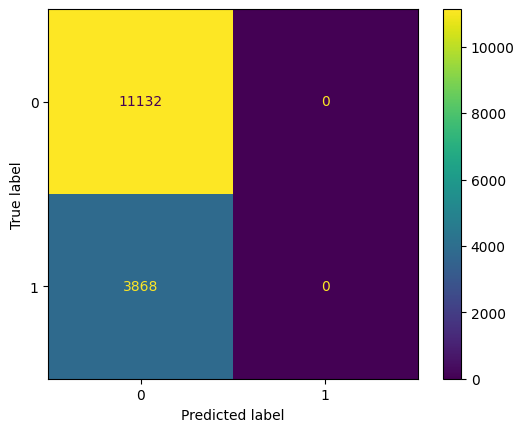

In [43]:
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
#
logreg = LogisticRegression(random_state=42)
# fit the model with data

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()